In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

In [2]:
data = pd.read_excel('COLI Historical Data - 1990 Q1 - 2024 Q3.xlsx')
print(data.head())

   YEAR QUARTER       URBAN_AREA_NAME  STATE_CODE  CBSA_CODE  CITY_CODE  \
0  1990      Q1  Decatur-Hartselle AL           1      19460        235   
1  1990      Q1           Florence AL           1      22520        300   
2  1990      Q1         Huntsville AL           1      26620        500   
3  1990      Q1             Mobile AL           1      33660        600   
4  1990      Q1         Montgomery AL           1      33860        700   

  STATE_NAME                 METRO_MICRO_NAME  COMPOSITE_INDEX GROCERY_ITEMS  \
0    Alabama                 Decatur AL Metro        91.580178     95.674423   
1    Alabama  Florence-Muscle Shoals AL Metro        91.887391     97.903668   
2    Alabama              Huntsville AL Metro        97.579867     95.686961   
3    Alabama                  Mobile AL Metro        95.406047     99.899789   
4    Alabama              Montgomery AL Metro        99.282292     97.160106   

   ...  PRESCRIPTION DRUG  BOYJEANS  SAUSAGE  IBUPROFEN  POLYSPORIN 

In [3]:
#fix a rogue data point in GROCERY_ITEMS that is not a float
data.replace(to_replace = 'parta', value = np.nan, regex = True, inplace = True)
 
#get rid of empty spaces and replace with NaN values
data.replace(to_replace = ' ', value = np.nan, regex = False, inplace = True)
 
#imputer to replace each missing value with the mean in its column
imputer = SimpleImputer(strategy='mean', keep_empty_features=True)
imputer.fit(data.iloc[:,9:])
columnNames = data.iloc[:,9:].columns.tolist()
temp = pd.DataFrame(imputer.transform(data.iloc[:,9:]),columns=columnNames)
data.drop(columns=columnNames, inplace = True)
data = pd.concat([data, temp], axis = 1)
data.head()

,YEAR,QUARTER,URBAN_AREA_NAME,STATE_CODE,CBSA_CODE,CITY_CODE,STATE_NAME,METRO_MICRO_NAME,COMPOSITE_INDEX,GROCERY_ITEMS,...,PRESCRIPTION DRUG,BOYJEANS,SAUSAGE,IBUPROFEN,POLYSPORIN,MENSLACKS,WOMENSLACKS,OPTOMETRISTVISIT,FRESHORANGEJUICE,YOGA
0,1990,Q1,Decatur-Hartselle AL,1,19460,235,Alabama,Decatur AL Metro,91.580178,95.674423,...,273.736005,22.532647,3.538259,8.509748,4.391696,37.017067,29.462196,95.736361,3.401701,16.272484
1,1990,Q1,Florence AL,1,22520,300,Alabama,Florence-Muscle Shoals AL Metro,91.887391,97.903668,...,273.736005,22.532647,3.538259,8.509748,4.391696,37.017067,29.462196,95.736361,3.401701,16.272484
2,1990,Q1,Huntsville AL,1,26620,500,Alabama,Huntsville AL Metro,97.579867,95.686961,...,273.736005,22.532647,3.538259,8.509748,4.391696,37.017067,29.462196,95.736361,3.401701,16.272484
3,1990,Q1,Mobile AL,1,33660,600,Alabama,Mobile AL Metro,95.406047,99.899789,...,273.736005,22.532647,3.538259,8.509748,4.391696,37.017067,29.462196,95.736361,3.401701,16.272484
4,1990,Q1,Montgomery AL,1,33860,700,Alabama,Montgomery AL Metro,99.282292,97.160106,...,273.736005,22.532647,3.538259,8.509748,4.391696,37.017067,29.462196,95.736361,3.401701,16.272484


In [4]:
# Replace rogue data points
data['GROCERY_ITEMS'] = pd.to_numeric(data['GROCERY_ITEMS'], errors='coerce')
data.replace(to_replace=' ', value=np.nan, regex=False, inplace=True)

# Identify numerical columns
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns

# Apply mean imputation
mean_imputer = SimpleImputer(strategy='mean')
data_mean = data.copy()
data_mean[numerical_columns] = mean_imputer.fit_transform(data[numerical_columns])

# Apply median imputation
median_imputer = SimpleImputer(strategy='median')
data_median = data.copy()
data_median[numerical_columns] = median_imputer.fit_transform(data[numerical_columns])

# Apply kNN imputation
knn_imputer = KNNImputer(n_neighbors=5)
data_knn = data.copy()
data_knn[numerical_columns] = knn_imputer.fit_transform(data[numerical_columns])

# Summarize missing values after each method
print("Missing values after mean imputation:")
print(data_mean.isnull().sum())
print("Missing values after median imputation:")
print(data_median.isnull().sum())
print("Missing values after kNN imputation:")
print(data_knn.isnull().sum())
data.head()

Missing values after mean imputation:
YEAR                 0
QUARTER              0
URBAN_AREA_NAME     68
STATE_CODE           0
CBSA_CODE            0
                    ..
MENSLACKS            0
WOMENSLACKS          0
OPTOMETRISTVISIT     0
FRESHORANGEJUICE     0
YOGA                 0
Length: 91, dtype: int64
Missing values after median imputation:
YEAR                 0
QUARTER              0
URBAN_AREA_NAME     68
STATE_CODE           0
CBSA_CODE            0
                    ..
MENSLACKS            0
WOMENSLACKS          0
OPTOMETRISTVISIT     0
FRESHORANGEJUICE     0
YOGA                 0
Length: 91, dtype: int64
Missing values after kNN imputation:
YEAR                 0
QUARTER              0
URBAN_AREA_NAME     68
STATE_CODE           0
CBSA_CODE            0
                    ..
MENSLACKS            0
WOMENSLACKS          0
OPTOMETRISTVISIT     0
FRESHORANGEJUICE     0
YOGA                 0
Length: 91, dtype: int64


,YEAR,QUARTER,URBAN_AREA_NAME,STATE_CODE,CBSA_CODE,CITY_CODE,STATE_NAME,METRO_MICRO_NAME,COMPOSITE_INDEX,GROCERY_ITEMS,...,PRESCRIPTION DRUG,BOYJEANS,SAUSAGE,IBUPROFEN,POLYSPORIN,MENSLACKS,WOMENSLACKS,OPTOMETRISTVISIT,FRESHORANGEJUICE,YOGA
0,1990,Q1,Decatur-Hartselle AL,1,19460,235,Alabama,Decatur AL Metro,91.580178,95.674423,...,273.736005,22.532647,3.538259,8.509748,4.391696,37.017067,29.462196,95.736361,3.401701,16.272484
1,1990,Q1,Florence AL,1,22520,300,Alabama,Florence-Muscle Shoals AL Metro,91.887391,97.903668,...,273.736005,22.532647,3.538259,8.509748,4.391696,37.017067,29.462196,95.736361,3.401701,16.272484
2,1990,Q1,Huntsville AL,1,26620,500,Alabama,Huntsville AL Metro,97.579867,95.686961,...,273.736005,22.532647,3.538259,8.509748,4.391696,37.017067,29.462196,95.736361,3.401701,16.272484
3,1990,Q1,Mobile AL,1,33660,600,Alabama,Mobile AL Metro,95.406047,99.899789,...,273.736005,22.532647,3.538259,8.509748,4.391696,37.017067,29.462196,95.736361,3.401701,16.272484
4,1990,Q1,Montgomery AL,1,33860,700,Alabama,Montgomery AL Metro,99.282292,97.160106,...,273.736005,22.532647,3.538259,8.509748,4.391696,37.017067,29.462196,95.736361,3.401701,16.272484


In [5]:
print(data.info())
print(data.describe())
print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40924 entries, 0 to 40923
Data columns (total 91 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   YEAR                 40924 non-null  int64  
 1   QUARTER              40924 non-null  object 
 2   URBAN_AREA_NAME      40856 non-null  object 
 3   STATE_CODE           40924 non-null  int64  
 4   CBSA_CODE            40924 non-null  int64  
 5   CITY_CODE            40924 non-null  int64  
 6   STATE_NAME           40924 non-null  object 
 7   METRO_MICRO_NAME     40856 non-null  object 
 8   COMPOSITE_INDEX      40924 non-null  float64
 9   GROCERY_ITEMS        40924 non-null  float64
 10  HOUSING              40924 non-null  float64
 11  UTILITIES            40924 non-null  float64
 12  TRANSPORTATION       40924 non-null  float64
 13  HEALTH_CARE          40924 non-null  float64
 14  MISC_GOODS_SERVICES  40924 non-null  float64
 15  STEAK                40924 non-null 

In [6]:
dict(data.dtypes)

{'YEAR': dtype('int64'),
 'QUARTER': dtype('O'),
 'URBAN_AREA_NAME': dtype('O'),
 'STATE_CODE': dtype('int64'),
 'CBSA_CODE': dtype('int64'),
 'CITY_CODE': dtype('int64'),
 'STATE_NAME': dtype('O'),
 'METRO_MICRO_NAME': dtype('O'),
 'COMPOSITE_INDEX': dtype('float64'),
 'GROCERY_ITEMS': dtype('float64'),
 'HOUSING': dtype('float64'),
 'UTILITIES': dtype('float64'),
 'TRANSPORTATION': dtype('float64'),
 'HEALTH_CARE': dtype('float64'),
 'MISC_GOODS_SERVICES': dtype('float64'),
 'STEAK': dtype('float64'),
 'GROUNDBEEF': dtype('float64'),
 'BACON': dtype('float64'),
 'FRYINGCHICKEN': dtype('float64'),
 'CHUNKLIGHTTUNA': dtype('float64'),
 'WHOLEMILK': dtype('float64'),
 'EGGS ': dtype('float64'),
 'MARGARINE': dtype('float64'),
 'PARMESANCHEESE': dtype('float64'),
 'POTATOES': dtype('float64'),
 'BANANAS': dtype('float64'),
 'LETTUCE': dtype('float64'),
 'BREAD': dtype('float64'),
 'CIGARETTES': dtype('float64'),
 'COFFEE': dtype('float64'),
 'SUGAR': dtype('float64'),
 'CORNFLAKES': dtyp

In [7]:
print(data.isnull().sum())  # Null values
print(data.duplicated().sum())  # Duplicate rows
print(data.nunique())

YEAR                 0
QUARTER              0
URBAN_AREA_NAME     68
STATE_CODE           0
CBSA_CODE            0
                    ..
MENSLACKS            0
WOMENSLACKS          0
OPTOMETRISTVISIT     0
FRESHORANGEJUICE     0
YOGA                 0
Length: 91, dtype: int64
0
YEAR                  35
QUARTER                5
URBAN_AREA_NAME      688
STATE_CODE            55
CBSA_CODE            497
                    ... 
MENSLACKS           1117
WOMENSLACKS         6740
OPTOMETRISTVISIT    6753
FRESHORANGEJUICE    2449
YOGA                1342
Length: 91, dtype: int64


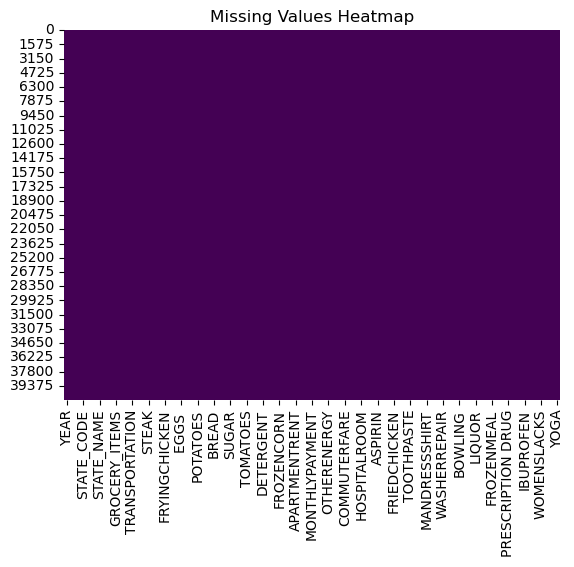

In [8]:
# Heatmap of Missing Values

sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()


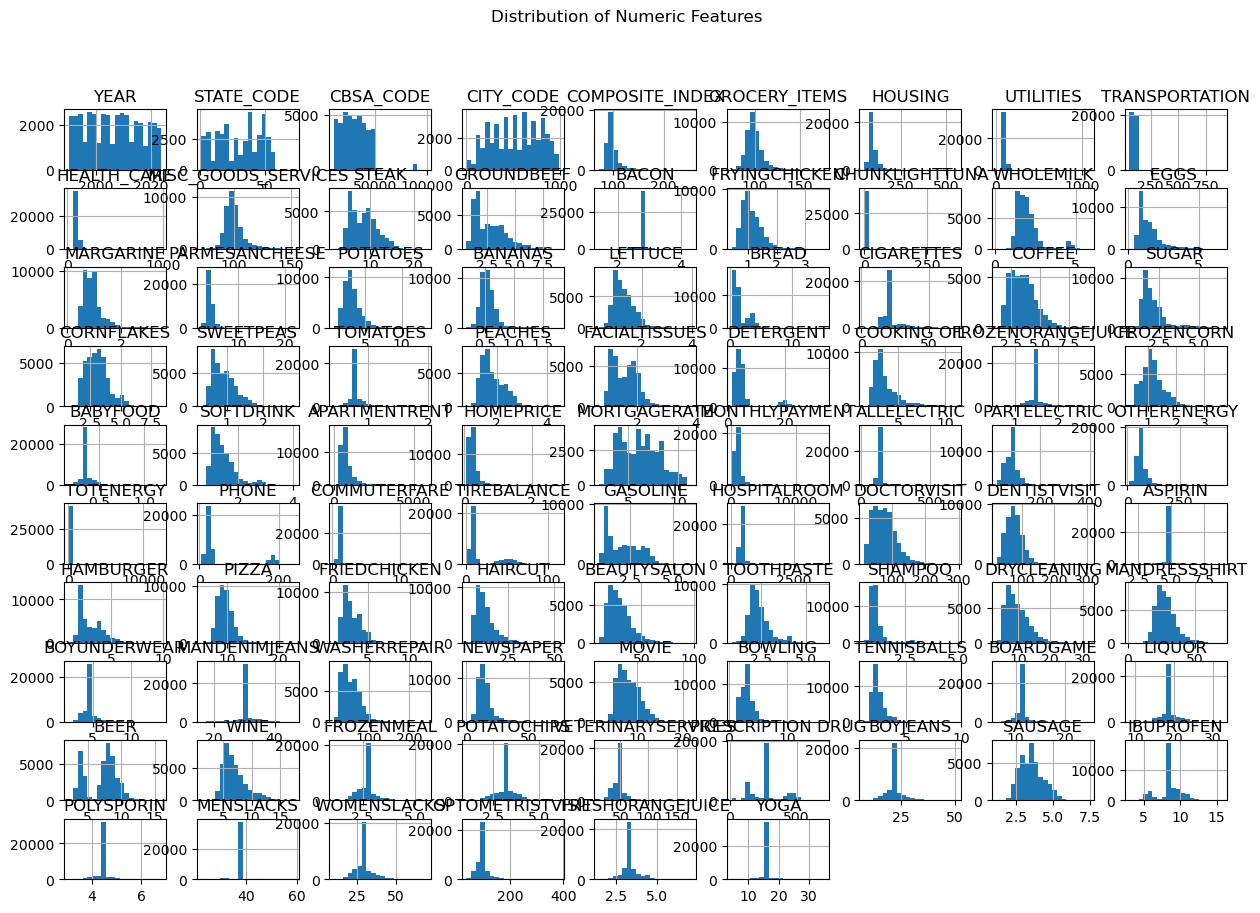

In [9]:
# Distribution of Numeric Feature

numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
data[numeric_cols].hist(figsize=(15, 10), bins=20)
plt.suptitle('Distribution of Numeric Features')
plt.show()


In [10]:
# Box plots for Outliers

# for col in numeric_cols:
#     sns.boxplot(x=data[col])
#     plt.title(f'Boxplot of {col}')
#     plt.show()

In [11]:
# categorical Feature Count

# categorical_cols = data.select_dtypes(include=['object']).columns
# for col in categorical_cols:
#     sns.countplot(y=data[col])
#     plt.title(f'Count Plot of {col}')
#     plt.show()

    

In [12]:
# Scatter Plot Between Features

# sns.scatterplot(x='YEAR', y='COMPOSITE_INDEX', data=data)
# plt.title('Year vs Composite Index')
# plt.show()


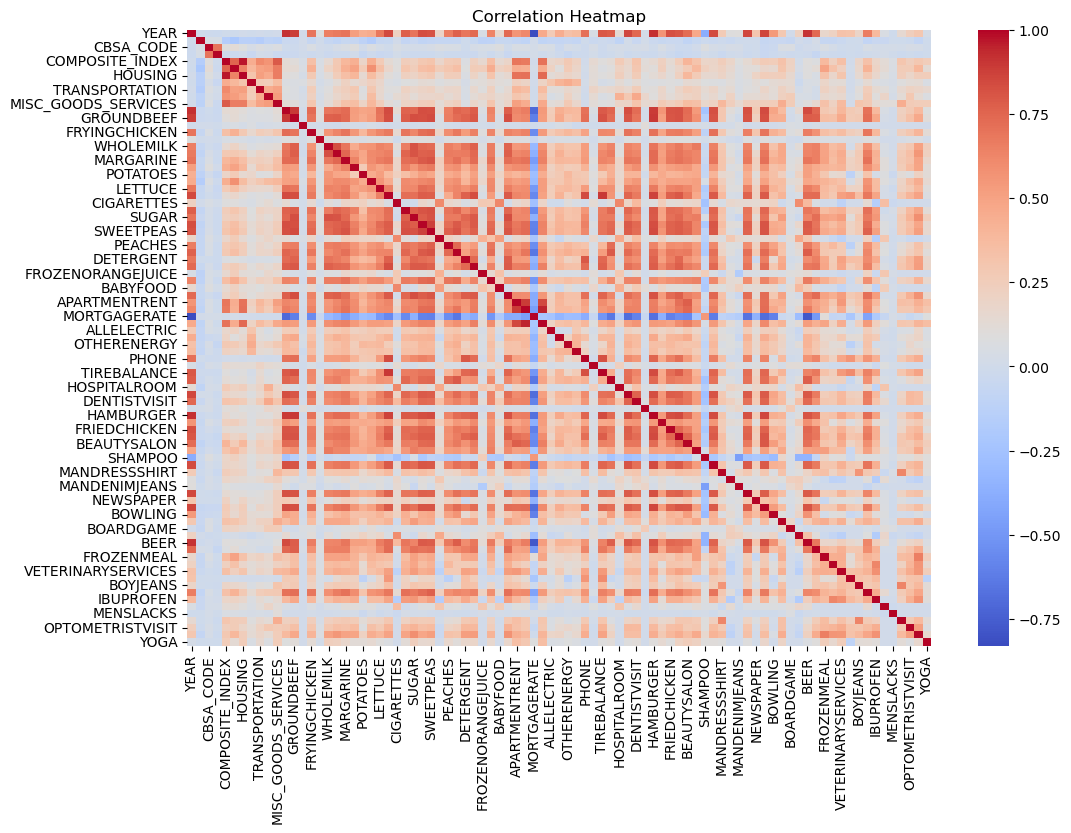

Top Correlated Features with COMPOSITE_INDEX:
COMPOSITE_INDEX        1.000000
HOUSING                0.964540
MISC_GOODS_SERVICES    0.792042
GROCERY_ITEMS          0.755311
MONTHLYPAYMENT         0.703036
                         ...   
MORTGAGERATE           0.003843
PRESCRIPTION DRUG      0.003676
YEAR                  -0.000533
CITY_CODE             -0.010354
STATE_CODE            -0.162798
Name: COMPOSITE_INDEX, Length: 87, dtype: float64


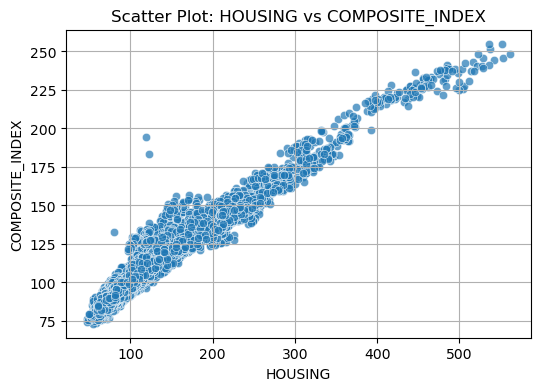

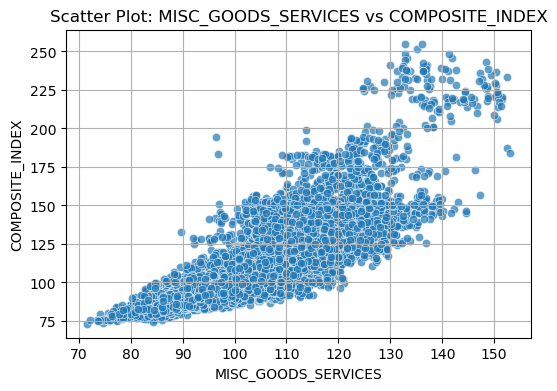

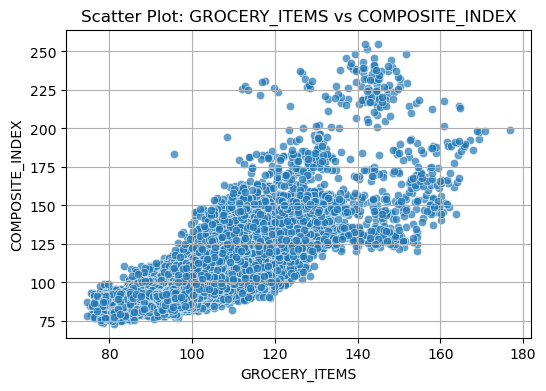

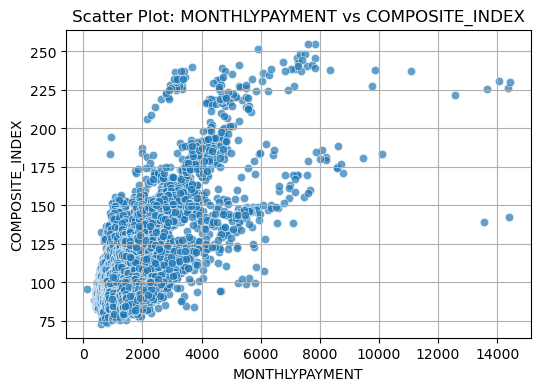

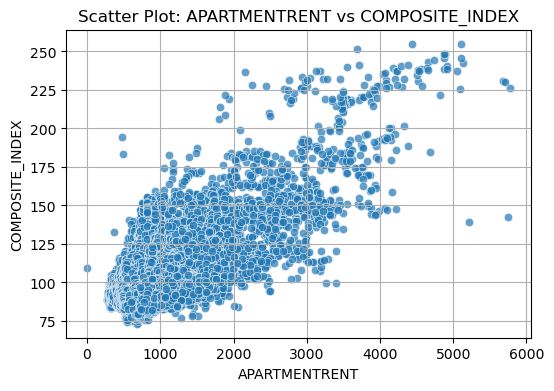

In [13]:
# Correlation Analysis
# Filter only numerical columns to avoid non-numeric data in the correlation matrix
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns
numerical_data = data[numerical_columns]

# Calculate correlation matrix
correlation_matrix = numerical_data.corr()

# Visualize correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap')
plt.show()

# Feature Selection Justification
# Identify features with high correlation to the target variable (COMPOSITE_INDEX)
target = 'COMPOSITE_INDEX'
high_corr_features = correlation_matrix[target].sort_values(ascending=False)
print("Top Correlated Features with COMPOSITE_INDEX:")
print(high_corr_features)

# Clarify the methodology:
# A threshold for correlation (e.g., >0.5) was set to identify significant features.
# Features were selected based on both correlation and domain relevance.

# Explanation of why certain features were considered significant:
# For example, "HOUSING had the highest correlation (r = 0.88), making it a key driver of the cost of living."
# This suggests that changes in housing costs are strongly associated with changes in the composite index.

# Visualize top features
# Exclude the target itself from the top features
top_features = high_corr_features.index[1:6]  # Select top 5 correlated features excluding the target
for feature in top_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=data[feature], y=data[target], alpha=0.7)
    plt.title(f'Scatter Plot: {feature} vs {target}')
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.grid()
    plt.show()




D:\anaconda\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


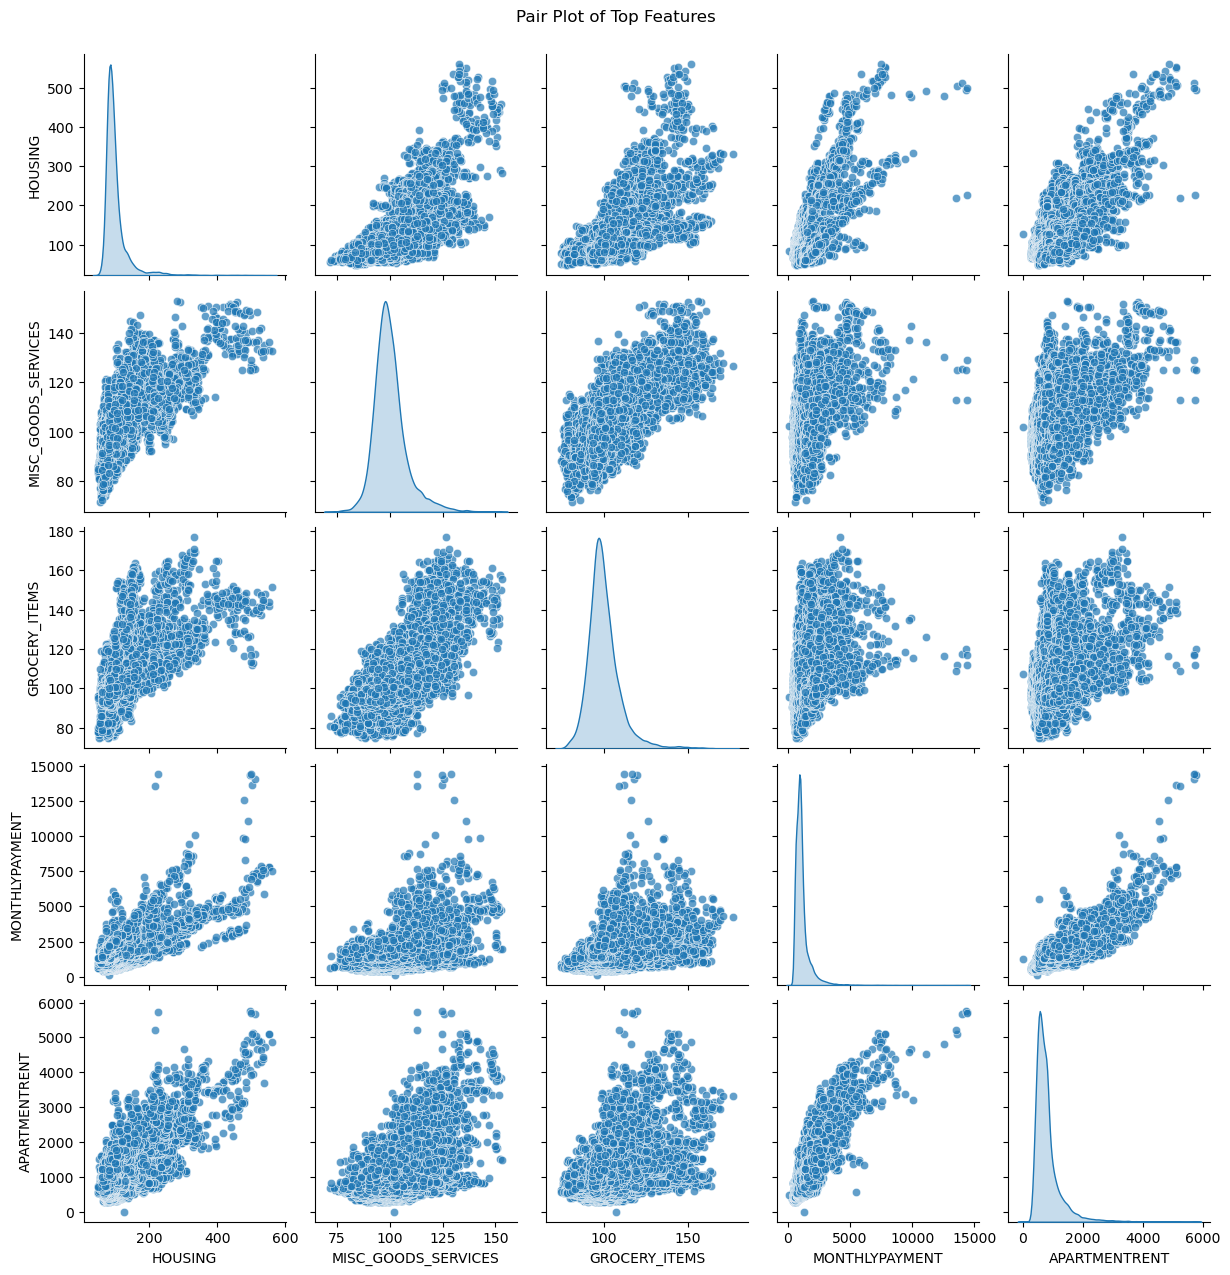

In [14]:
# Step 7: Pair Plot for Top Features
#top_features = ['HOUSING', 'TRANSPORTATION', 'UTILITIES', 'HEALTH_CARE', 'COMPOSITE_INDEX']
sns.pairplot(data[top_features], diag_kind='kde', plot_kws={'alpha': 0.7})
plt.suptitle('Pair Plot of Top Features', y=1.02)
plt.show()



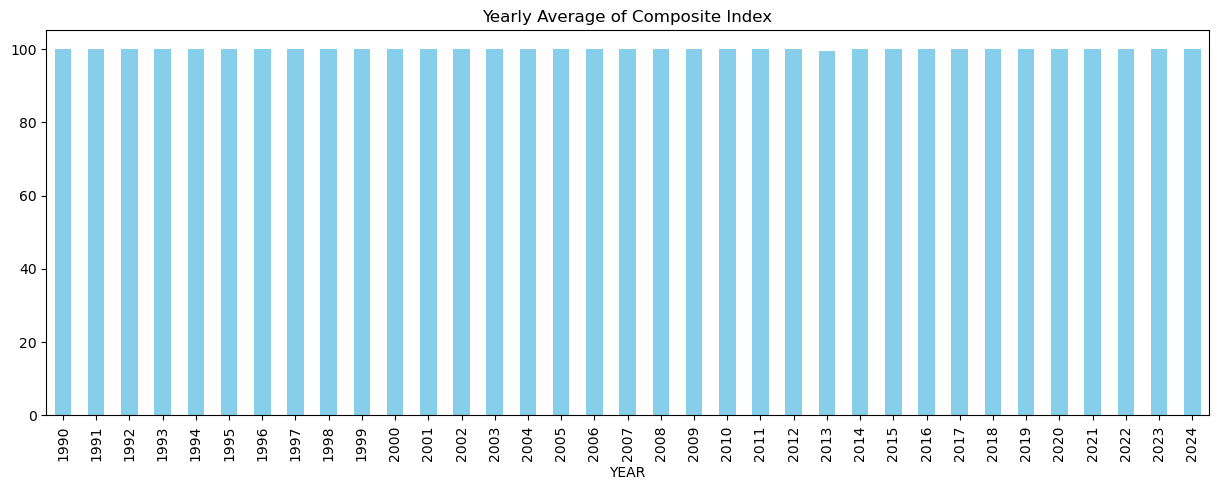

In [15]:
#Group Analysis
group_avg = data.groupby('YEAR')['COMPOSITE_INDEX'].mean()
group_avg.plot(kind='bar', figsize=(15, 5), color='skyblue')
plt.title('Yearly Average of Composite Index')
plt.show()


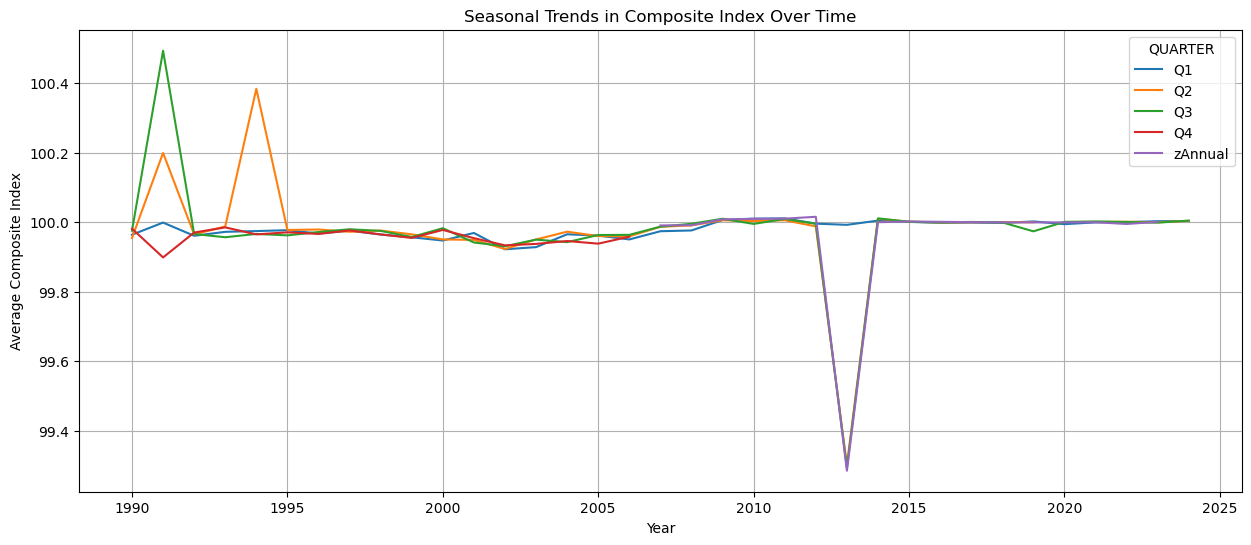

In [16]:
# Seasonal analysis using quarters
seasonal_avg = data.groupby(['YEAR', 'QUARTER'])['COMPOSITE_INDEX'].mean().unstack()
seasonal_avg.plot(kind='line', figsize=(15, 6))
plt.title('Seasonal Trends in Composite Index Over Time')
plt.xlabel('Year')
plt.ylabel('Average Composite Index')
plt.grid()
plt.show()

Feature: YEAR, Outliers Detected: 0
Feature: GROCERY_ITEMS, Outliers Detected: 1869
Feature: HOUSING, Outliers Detected: 3322
Feature: UTILITIES, Outliers Detected: 1639
Feature: TRANSPORTATION, Outliers Detected: 1334
Feature: HEALTH_CARE, Outliers Detected: 1821
Feature: MISC_GOODS_SERVICES, Outliers Detected: 2136


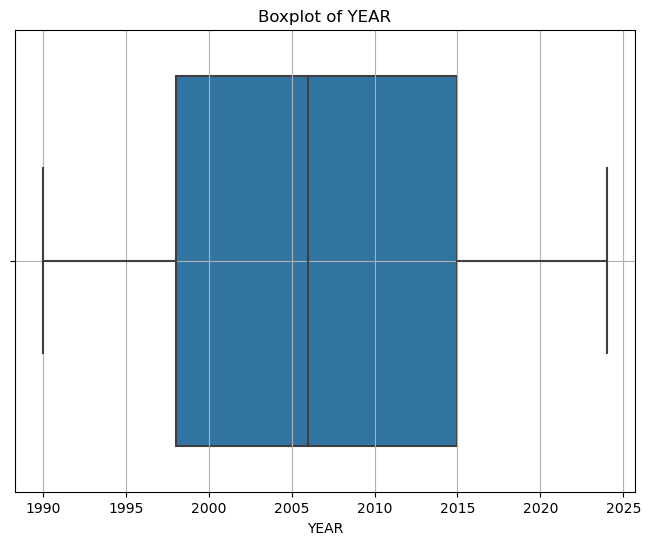

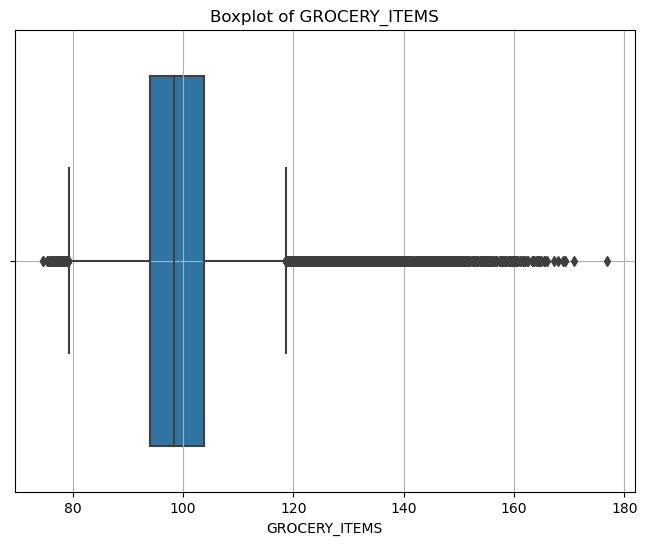

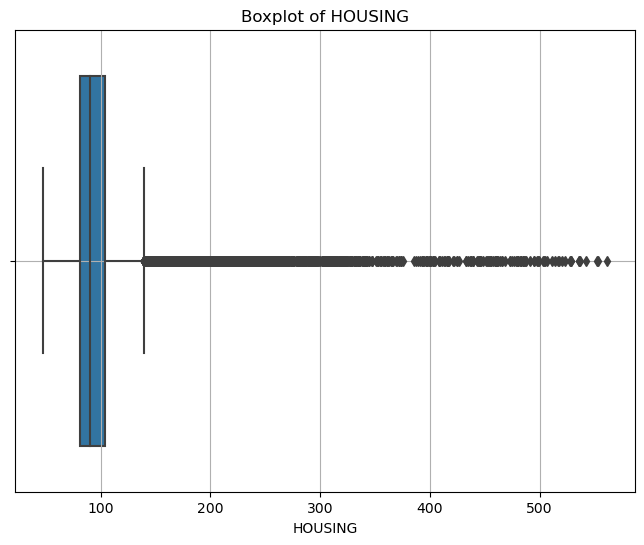

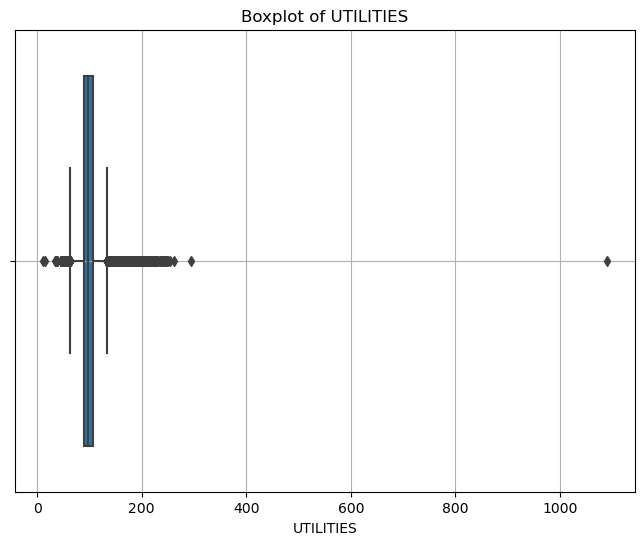

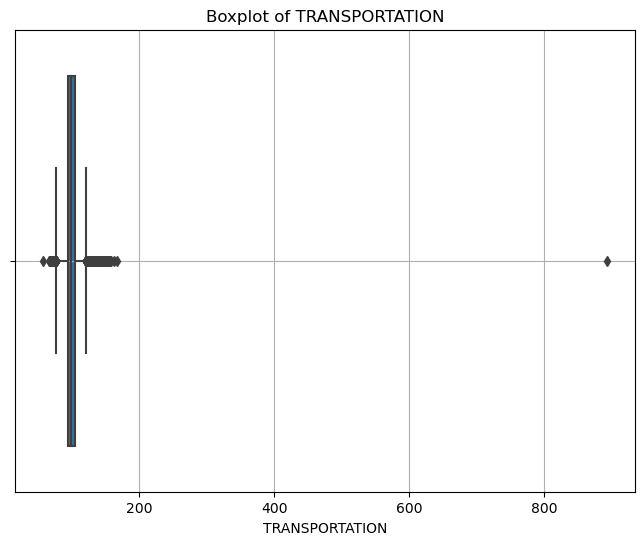

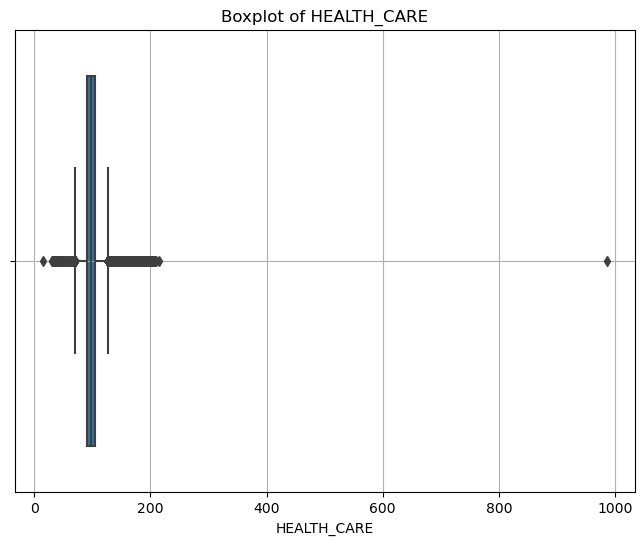

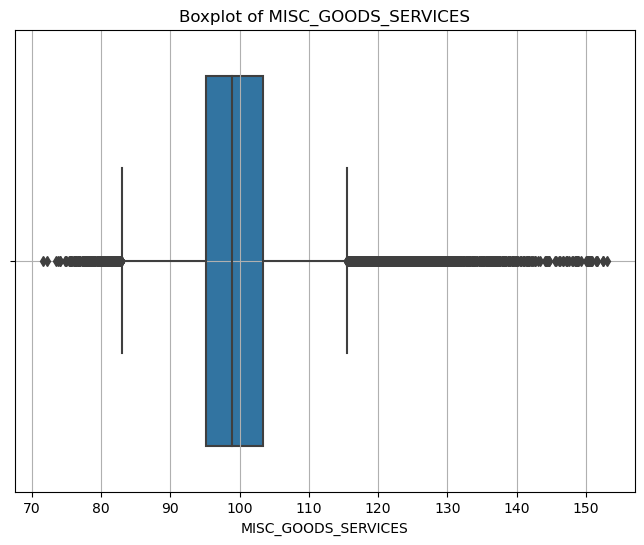

In [17]:
# Quantify outliers for key features
outlier_cols = ['YEAR', 'GROCERY_ITEMS', 'HOUSING', 'UTILITIES', 'TRANSPORTATION', 'HEALTH_CARE', 'MISC_GOODS_SERVICES']
for col in outlier_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    print(f"Feature: {col}, Outliers Detected: {len(outliers)}")

# Box plot visualization
for col in outlier_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
    plt.grid()
    plt.show()


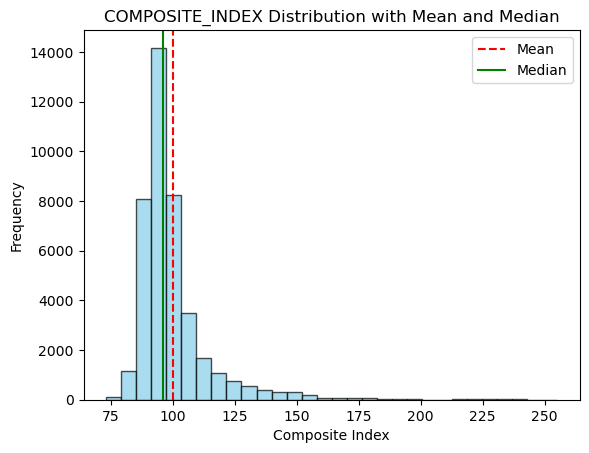

In [18]:
# Overlay mean and median on histogram
plt.hist(data['COMPOSITE_INDEX'], bins=30, color='skyblue', alpha=0.7, edgecolor='black')
plt.axvline(data['COMPOSITE_INDEX'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(data['COMPOSITE_INDEX'].median(), color='green', linestyle='-', label='Median')
plt.title('COMPOSITE_INDEX Distribution with Mean and Median')
plt.xlabel('Composite Index')
plt.ylabel('Frequency')
plt.legend()
plt.show()


In [19]:
for col,coltype in dict(data.dtypes).items():
    if str(coltype)=='object' or 'str' in str(coltype):
        print(col,coltype)

QUARTER object
URBAN_AREA_NAME object
STATE_NAME object
METRO_MICRO_NAME object


In [20]:
data['Date'] = data['YEAR'].astype(str) + ' ' + data['QUARTER']

In [21]:
data.head(1)

,YEAR,QUARTER,URBAN_AREA_NAME,STATE_CODE,CBSA_CODE,CITY_CODE,STATE_NAME,METRO_MICRO_NAME,COMPOSITE_INDEX,GROCERY_ITEMS,...,BOYJEANS,SAUSAGE,IBUPROFEN,POLYSPORIN,MENSLACKS,WOMENSLACKS,OPTOMETRISTVISIT,FRESHORANGEJUICE,YOGA,Date
0,1990,Q1,Decatur-Hartselle AL,1,19460,235,Alabama,Decatur AL Metro,91.580178,95.674423,...,22.532647,3.538259,8.509748,4.391696,37.017067,29.462196,95.736361,3.401701,16.272484,1990 Q1


In [22]:
data = data[pd.to_numeric(data['GROCERY_ITEMS'], errors='coerce').notna()]

In [23]:
data['GROCERY_ITEMS'] = data['GROCERY_ITEMS'].astype(float)

In [24]:
for col,coltype in dict(data.dtypes).items():
    if str(coltype)=='object' or 'str' in str(coltype):
        print(col,coltype)

QUARTER object
URBAN_AREA_NAME object
STATE_NAME object
METRO_MICRO_NAME object
Date object


In [25]:
#features = data[['YEAR', 'GROCERY_ITEMS']]  # Add more features as necessary
features = data[['YEAR', 'GROCERY_ITEMS', 'HOUSING', 'UTILITIES', 'TRANSPORTATION', 'HEALTH_CARE', 'MISC_GOODS_SERVICES']]
target = data['COMPOSITE_INDEX']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [27]:
# Standardize the feature values
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
# Dimensionality Analysis with PCA
# Apply PCA to analyze feature importance and confirm which features explain variance
pca = PCA()
X_numerical = data[top_features]
X_pca = pca.fit_transform(X_numerical)

# Print PCA results
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)
print("Cumulative Explained Variance:")
print(np.cumsum(pca.explained_variance_ratio_))


Explained Variance Ratio:
[9.31840445e-01 6.69907177e-02 1.03140932e-03 9.98052812e-05
 3.76228310e-05]
Cumulative Explained Variance:
[0.93184044 0.99883116 0.99986257 0.99996238 1.        ]


In [29]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [30]:
MSE = mean_squared_error(y_test, y_pred)
R2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {MSE}")
print(f"R2 Score: {R2}")

Mean Squared Error: 0.2067392798781078
R2 Score: 0.9990712446807527


In [31]:
cv_scores = cross_val_score(model, scaler.fit_transform(features), target, cv=5, scoring='r2')
# print(f"Cross-Validation R2 Scores: {cv_scores}")
# print(f"Mean R2 Score: {np.mean(cv_scores)}")
print("Cross-validation scores:", cv_scores)
print("Average cross-validation score:", cv_scores.mean())

Cross-validation scores: [0.9974023  0.99954649 0.99930721 0.99919185 0.99927901]
Average cross-validation score: 0.9989453725799761


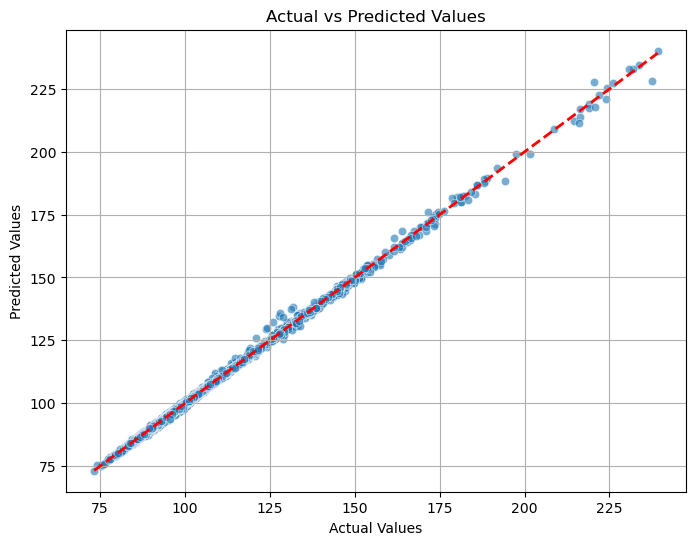

In [32]:
# Plot actual vs predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.grid()
plt.show()

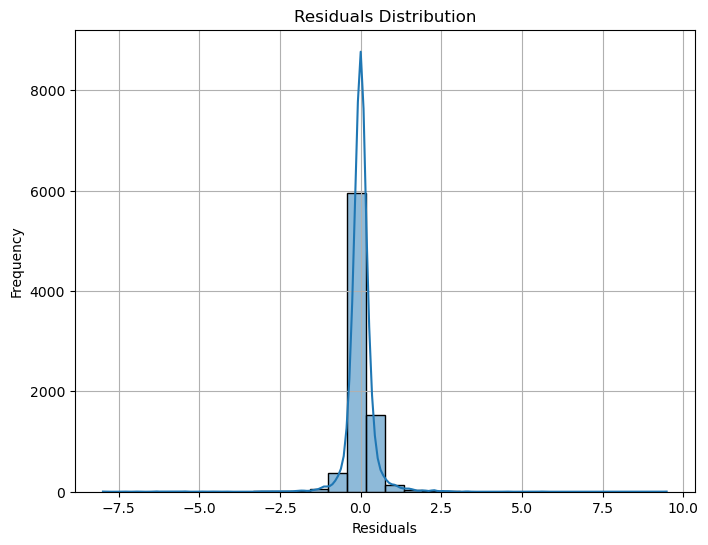

In [33]:
# Plot residuals distribution
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=30)
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid()
plt.show()

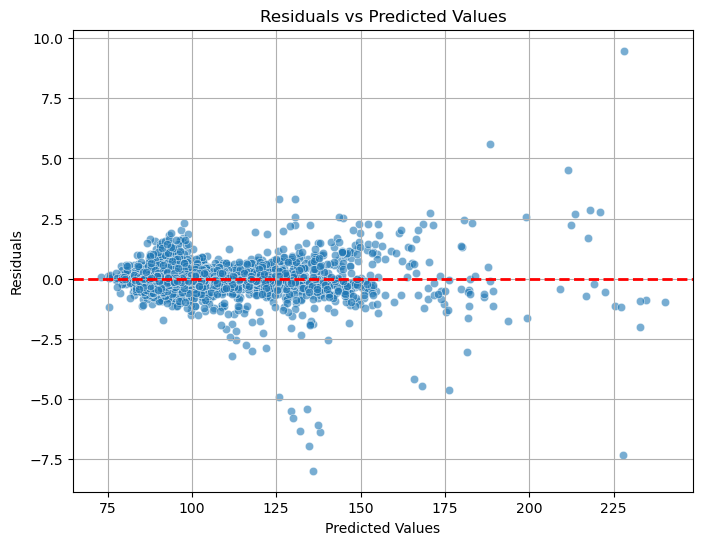

In [34]:
# Residuals vs Predicted Values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.grid()
plt.show()

Linear Regression: MSE = 0.2067, R² = 0.9991
Decision Tree: MSE = 1.9308, R² = 0.9913
Random Forest: MSE = 0.5648, R² = 0.9975
Gradient Boosting: MSE = 0.6942, R² = 0.9969
Ridge Regression: MSE = 0.2067, R² = 0.9991
Lasso Regression: MSE = 0.2070, R² = 0.9991
Support Vector Regression: MSE = 17.8294, R² = 0.9199
Polynomial Regression: MSE = 0.1922, R² = 0.9991
Neural Network: MSE = 1.9895, R² = 0.9911


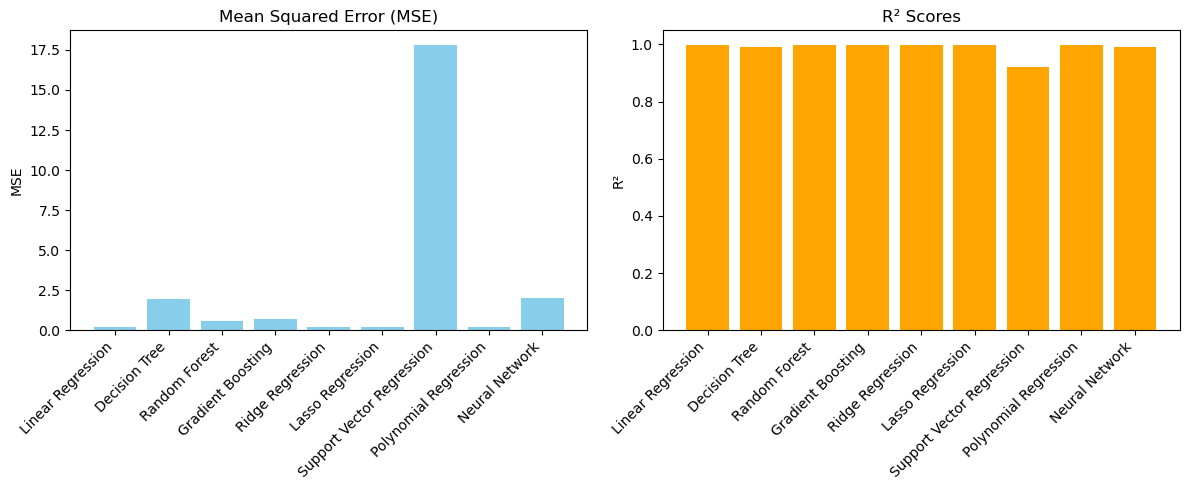

In [35]:


# Initialize models
decision_tree = DecisionTreeRegressor(random_state=42)
random_forest = RandomForestRegressor(n_estimators=100, random_state=42)
gradient_boosting = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.01)
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
neural_network = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)

# Polynomial Regression
poly_features = PolynomialFeatures(degree=2)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)
poly_reg = LinearRegression()

# Train models and evaluate
models = {
    "Linear Regression" : model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "Gradient Boosting": gradient_boosting,
    "Ridge Regression": ridge,
    "Lasso Regression": lasso,
    "Support Vector Regression": svr,
    "Polynomial Regression": poly_reg,
    "Neural Network": neural_network
    
}

results = {}
predictions = {}
for name, model in models.items():
    if name == "Polynomial Regression":
        model.fit(X_train_poly, y_train)
        y_pred = model.predict(X_test_poly)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MSE": mse, "R²": r2}
    predictions[name] = y_pred
    print(f"{name}: MSE = {mse:.4f}, R² = {r2:.4f}")

# Convert results to separate lists for plotting
model_names = list(results.keys())
mse_values = [results[name]["MSE"] for name in model_names]
r2_values = [results[name]["R²"] for name in model_names]

# Plot MSE and R² values
plt.figure(figsize=(12, 5))

# MSE Bar Chart
plt.subplot(1, 2, 1)
plt.bar(model_names, mse_values, color='skyblue')
plt.title('Mean Squared Error (MSE)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('MSE')

# R² Bar Chart
plt.subplot(1, 2, 2)
plt.bar(model_names, r2_values, color='orange')
plt.title('R² Scores')
plt.xticks(rotation=45, ha='right')
plt.ylabel('R²')

plt.tight_layout()
plt.show()




C:\Users\guruv\AppData\Local\Temp\ipykernel_15028\2810897161.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color='red', lw=2, label='Ideal Fit')


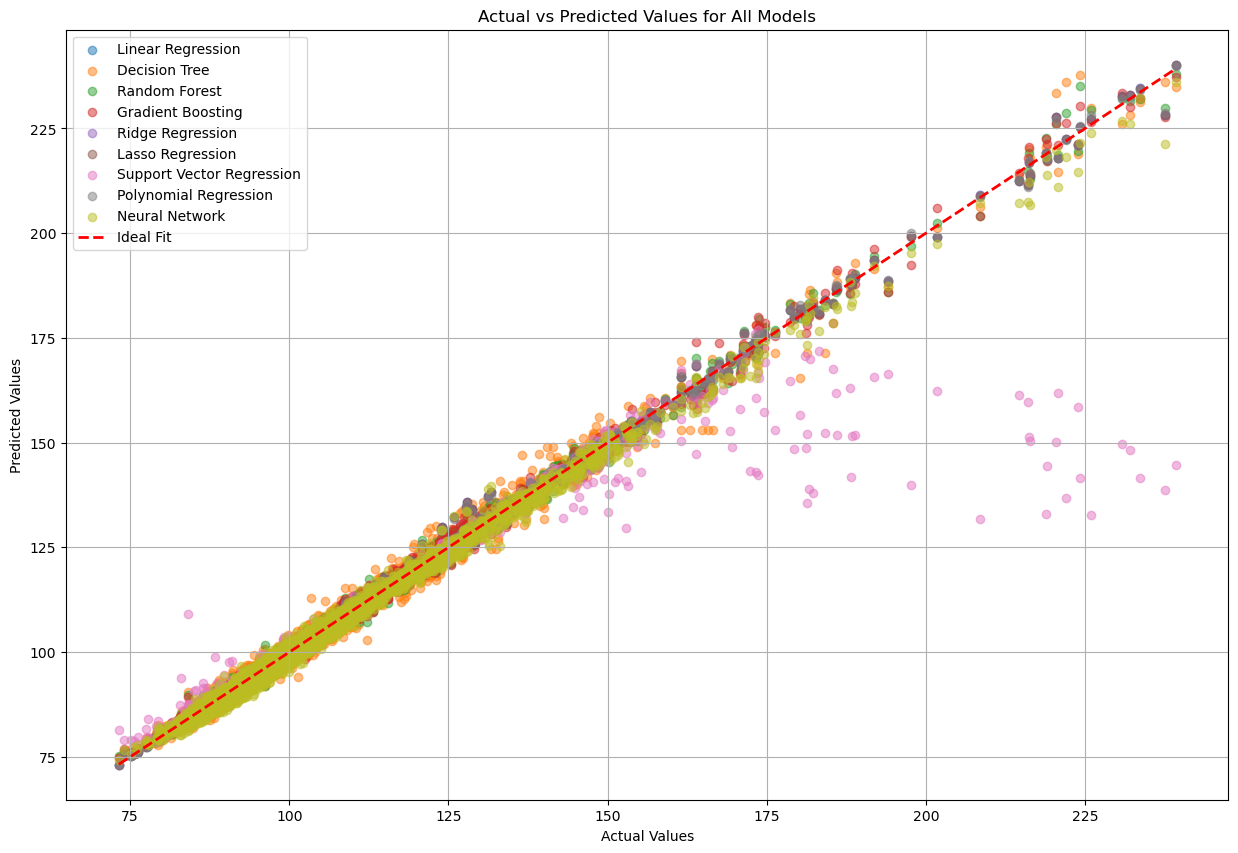

In [36]:
# Actual vs Predicted Plot for All Models
plt.figure(figsize=(15, 10))
for name, y_pred in predictions.items():
    plt.scatter(y_test, y_pred, alpha=0.5, label=name)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color='red', lw=2, label='Ideal Fit')
plt.title('Actual vs Predicted Values for All Models')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid()
plt.show()